<a href="https://colab.research.google.com/github/krupalithakur/CellposeVsCellSAM/blob/main/Disseratation_2_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q "cellpose[all]" opencv-python-headless pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.4 MB/s eta 0:00:00
   ━

In [2]:
# ───────────────────────────────────────────────────────────────
# 1.  Install Cellpose  +  CellSAM  (official repo)
# ───────────────────────────────────────────────────────────────
!pip install -q "cellpose[all]"                   # nuclei baseline
!pip install -q git+https://github.com/vanvalenlab/cellSAM.git
#     ^ no 'git clone', no requirements file – pip handles everything

# 2.  (optional) check GPU + import sanity
import torch, cellpose, cellSAM
print("CUDA available:", torch.cuda.is_available())
from cellSAM import segment_cellular_image
print("CellSAM import OK ✔️")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.11.13 
torch version:  	2.6.0+cu124! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


CUDA available: True
CellSAM import OK ✔️


In [3]:
import torch
print("CUDA?", torch.cuda.is_available())
!nvidia-smi | head -n 10

CUDA? True
Thu Jul 10 10:30:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       2MiB /  15360MiB |      0%      Default |


In [4]:
# ░░░  IMPORT THE 10-MICROGRAPH SUBSET  ░░░
# Adjust RAW_DIR / GT_DIR if you moved the folders
RAW_DIR = "/content/drive/MyDrive/S-BIAD634/dataset/rawimages"
GT_DIR  = "/content/drive/MyDrive/S-BIAD634/dataset/singlecell_groundtruth"

import glob, cv2
from pathlib import Path

# 1) Grab the first 10 TIFFs (or use whatever selection logic you like)
raw_paths  = sorted(glob.glob(f"{RAW_DIR}/*.tif"))[:10]

# 2) Derive the matching mask paths (same filename, different folder)
gt_paths   = [f"{GT_DIR}/{Path(p).name}" for p in raw_paths]

# 3) Load images → NumPy arrays  (16-bit safe)
images = [cv2.imread(p, cv2.IMREAD_ANYDEPTH) for p in raw_paths]
masks  = [cv2.imread(p, cv2.IMREAD_ANYDEPTH) for p in gt_paths]

print(f"Loaded {len(images)} images, {len(masks)} masks")
print(" image shape:", images[0].shape, "dtype:", images[0].dtype)

Loaded 10 images, 10 masks
 image shape: (914, 1225) dtype: uint8


Using 10 images for testing.


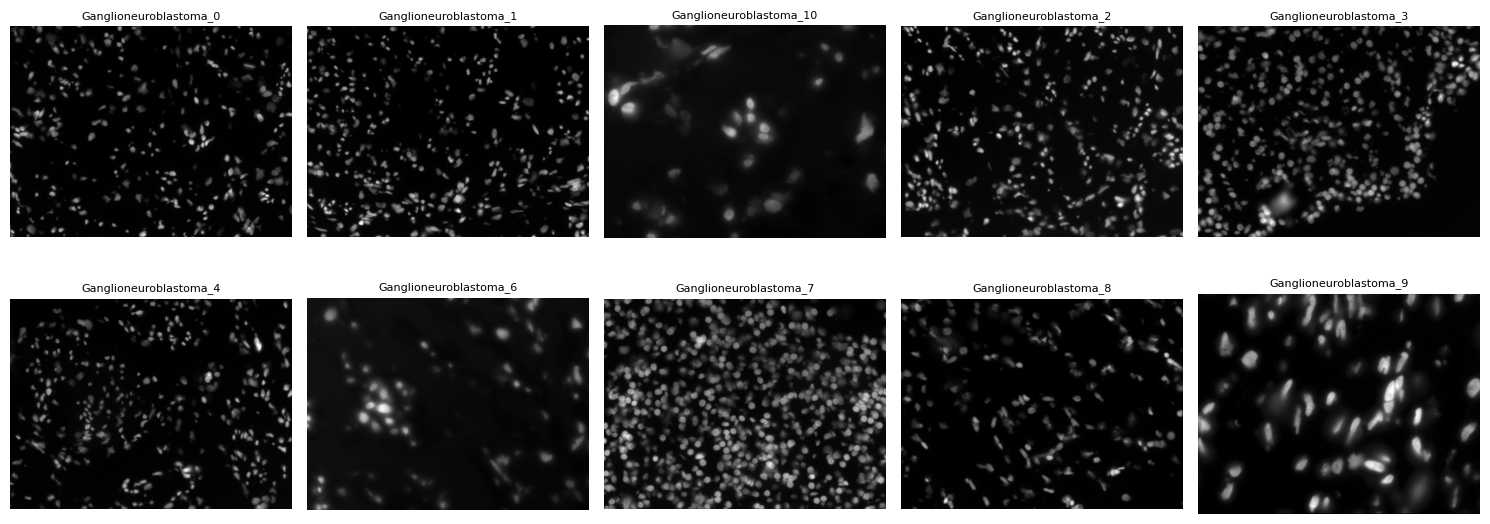

In [5]:
# =========================================================
# 1)  (OPTIONAL) pick a random 10 instead of the first 10
# =========================================================
import random
RANDOM_PICK = False          # set to True if you want random variety

if RANDOM_PICK:
    random.seed(42)
    idx = random.sample(range(len(raw_paths)), 10)
    raw_paths = [raw_paths[i] for i in idx]
    gt_paths  = [gt_paths[i]  for i in idx]
    images    = [images[i]    for i in idx]
    masks     = [masks[i]     for i in idx]    # keep lists in sync

print(f"Using {len(images)} images for testing.")

# =========================================================
# 2)  Quick thumbnail gallery (images only)
# =========================================================
import matplotlib.pyplot as plt
from pathlib import Path

def show_gallery(img_list, title_list=None, n_cols=5, cmap='gray'):
    n = len(img_list)
    n_rows = (n + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    for i, img in enumerate(img_list):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        ax.imshow(img, cmap=cmap)
        ax.axis('off')
        if title_list:
            ax.set_title(title_list[i], fontsize=8)
    plt.tight_layout()
    plt.show()

show_gallery(images, [Path(p).stem for p in raw_paths])

Running on: cuda


TypeError: Image data of dtype object cannot be converted to float

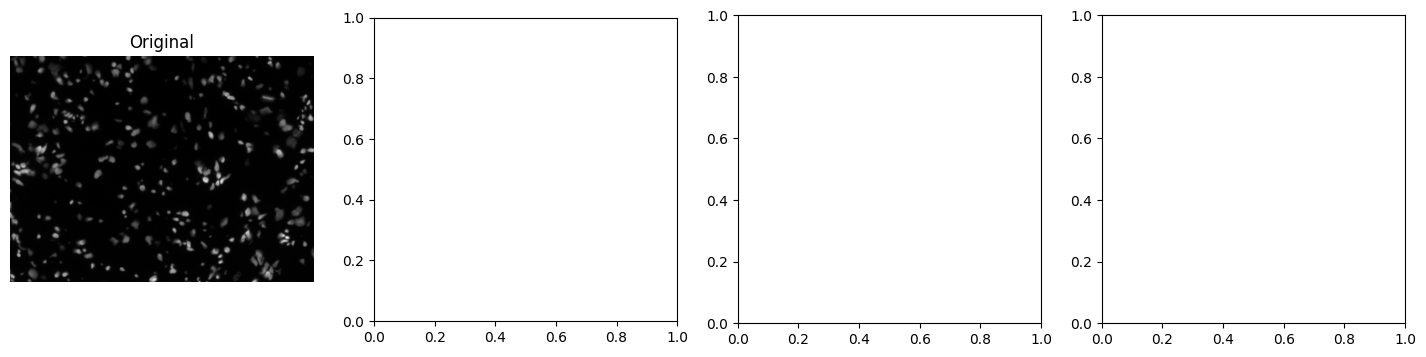

In [8]:
# ================================================================
#  SEGMENT WITH  ❱ Cellpose v4  +  cellSAM
# ================================================================
import os, cv2, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ─── 1.  Output folders (edit ROOT_OUT if you like) ─────────────
ROOT_OUT = "/content/drive/MyDrive/S-BIAD634/predictions"
CP_DIR   = f"{ROOT_OUT}/cellpose"
SAM_DIR  = f"{ROOT_OUT}/cellsam"
os.makedirs(CP_DIR,  exist_ok=True)
os.makedirs(SAM_DIR, exist_ok=True)

# ─── 2.  Load models  (new Cellpose API!) ───────────────────────
from cellpose import models
cp_model = models.CellposeModel(           # <-- v4 entry point
        gpu=torch.cuda.is_available(),
        model_type="nuclei")               # or "cyto", "cyto2", etc.

from cellSAM import segment_cellular_image
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

# ─── 3.  Predict, save, visualise, log rows ─────────────────────
rows = []

for img, gt_path, raw_path in zip(images, gt_paths, raw_paths):
    stem = Path(raw_path).stem

    # 3-a)  Cellpose
    cp_mask, *_ = cp_model.eval(img, channels=[0, 0])
    cp_out = f"{CP_DIR}/{stem}_cp.png"
    cv2.imwrite(cp_out, cp_mask.astype(np.uint16))

    # 3-b)  cellSAM
    sam_mask, *_ = segment_cellular_image(
        img.astype("float32"), device=DEVICE)
    sam_out = f"{SAM_DIR}/{stem}_sam.png"
    cv2.imwrite(sam_out, sam_mask.astype(np.uint16))

    # 3-c)  Collect for CSV
    rows += [
        dict(Image=raw_path, Annotation=gt_path,
             Model="Cellpose", Prediction=cp_out),
        dict(Image=raw_path, Annotation=gt_path,
             Model="CellSAM",  Prediction=sam_out)
    ]

    # 3-d)  Side-by-side visual check
    gt_img = cv2.imread(gt_path, cv2.IMREAD_ANYDEPTH)
    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    for a, im, title in zip(
            ax, [img, gt_img, cp_mask, sam_mask],
            ["Original", "GT", "Cellpose", "CellSAM"]):
        a.imshow(im, cmap='gray')
        a.set_title(title); a.axis('off')
    plt.suptitle(stem); plt.tight_layout(); plt.show()

print("✅  Predictions finished for all 10 images.")

# ─── 4.  Save results table ─────────────────────────────────────
df = pd.DataFrame(rows)
csv_path = f"{ROOT_OUT}/results_table.csv"
df.to_csv(csv_path, index=False)
print("📑  CSV saved →", csv_path)

In [10]:
import os, cv2
bad = []
for stem in [Path(p).stem for p in raw_paths]:
    for label, folder in [("cp", CP_DIR), ("sam", SAM_DIR)]:
        p = f"{folder}/{stem}_{label}.png"
        if not os.path.exists(p):
            bad.append(p)
        elif cv2.imread(p, cv2.IMREAD_UNCHANGED) is None:
            bad.append(p + "  (read==None)")
print("Problem files:", *bad or ["none"], sep="\n- ")

Problem files:
- /content/drive/MyDrive/S-BIAD634/predictions/cellpose/Ganglioneuroblastoma_1_cp.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellsam/Ganglioneuroblastoma_1_sam.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellpose/Ganglioneuroblastoma_10_cp.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellsam/Ganglioneuroblastoma_10_sam.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellpose/Ganglioneuroblastoma_2_cp.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellsam/Ganglioneuroblastoma_2_sam.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellpose/Ganglioneuroblastoma_3_cp.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellsam/Ganglioneuroblastoma_3_sam.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellpose/Ganglioneuroblastoma_4_cp.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellsam/Ganglioneuroblastoma_4_sam.png
- /content/drive/MyDrive/S-BIAD634/predictions/cellpose/Ganglioneuroblastoma_6_cp.png
- /content/drive/MyDrive/S-BIAD634/pr

In [11]:
import os, cv2, torch, numpy as np
from pathlib import Path
from cellpose import models
from cellSAM import segment_cellular_image

# ─── 1. paths & model handles ──────────────────────────────────────────────
CP_DIR   = "/content/drive/MyDrive/S-BIAD634/predictions/cellpose"
SAM_DIR  = "/content/drive/MyDrive/S-BIAD634/predictions/cellsam"
os.makedirs(CP_DIR,  exist_ok=True)
os.makedirs(SAM_DIR, exist_ok=True)

cp_model = models.CellposeModel(gpu=torch.cuda.is_available())
device   = "cuda" if torch.cuda.is_available() else "cpu"

# ─── 2. iterate over the 10 images ─────────────────────────────────────────
for img, raw_path in zip(images, raw_paths):
    stem   = Path(raw_path).stem
    cp_out = f"{CP_DIR}/{stem}_cp.png"
    sm_out = f"{SAM_DIR}/{stem}_sam.png"

    # ----- Cellpose (only if file missing) ---------------------------------
    if not os.path.exists(cp_out):
        cp_mask, *_ = cp_model.eval(img, channels=[0, 0])
        cv2.imwrite(cp_out, np.asarray(cp_mask, dtype=np.uint16))
        print(f"Cellpose ✔︎ {stem}")

    # ----- CellSAM (only if file missing) ----------------------------------
    if not os.path.exists(sm_out):
        sam_mask, *_ = segment_cellular_image(img.astype("float32"),
                                              device=device)
        cv2.imwrite(sm_out, np.asarray(sam_mask, dtype=np.uint16))
        print(f"CellSAM  ✔︎ {stem}")

print("✅  Missing predictions regenerated.")

Cellpose ✔︎ Ganglioneuroblastoma_1


CellSAM  ✔︎ Ganglioneuroblastoma_1
Cellpose ✔︎ Ganglioneuroblastoma_10


CellSAM  ✔︎ Ganglioneuroblastoma_10
Cellpose ✔︎ Ganglioneuroblastoma_2


/usr/local/lib/python3.11/dist-packages/cellSAM/sam_inference.py:272: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")


CellSAM  ✔︎ Ganglioneuroblastoma_2
Cellpose ✔︎ Ganglioneuroblastoma_3


CellSAM  ✔︎ Ganglioneuroblastoma_3
Cellpose ✔︎ Ganglioneuroblastoma_4


CellSAM  ✔︎ Ganglioneuroblastoma_4
Cellpose ✔︎ Ganglioneuroblastoma_6


CellSAM  ✔︎ Ganglioneuroblastoma_6
Cellpose ✔︎ Ganglioneuroblastoma_7


CellSAM  ✔︎ Ganglioneuroblastoma_7
Cellpose ✔︎ Ganglioneuroblastoma_8


CellSAM  ✔︎ Ganglioneuroblastoma_8
Cellpose ✔︎ Ganglioneuroblastoma_9
CellSAM  ✔︎ Ganglioneuroblastoma_9
✅  Missing predictions regenerated.


In [12]:
import pandas as pd, glob
rows = []
for raw_path, gt_path in zip(raw_paths, gt_paths):
    stem = Path(raw_path).stem
    rows += [
        dict(Image=raw_path, Annotation=gt_path,
             Model="Cellpose",
             Prediction=f"{CP_DIR}/{stem}_cp.png"),
        dict(Image=raw_path, Annotation=gt_path,
             Model="CellSAM",
             Prediction=f"{SAM_DIR}/{stem}_sam.png")
    ]
pd.DataFrame(rows).to_csv(f"{ROOT_OUT}/results_table.csv", index=False)
print("CSV refreshed ✔︎")

CSV refreshed ✔︎


,Original,Ground-truth,Cellpose,CellSAM
0,,missing,,
1,,missing,,
2,,missing,,
3,,missing,,
4,,missing,,
5,,missing,,
6,,missing,,
7,,missing,,
8,,missing,,
9,,missing,,

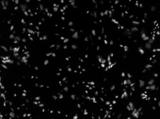
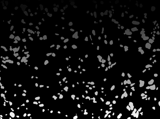
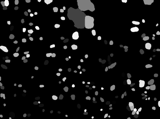
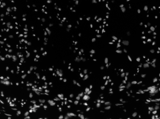
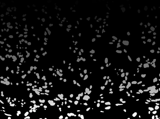
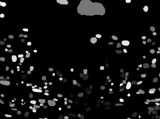
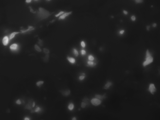
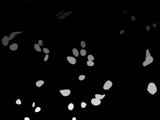
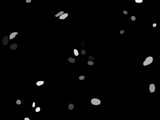
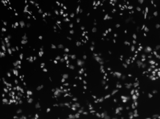
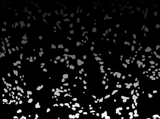
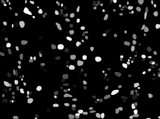
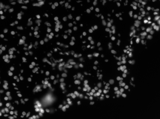
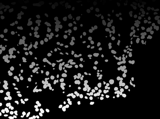
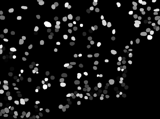
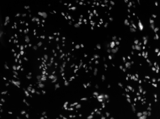
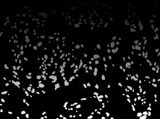
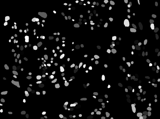
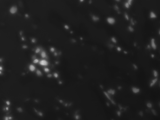
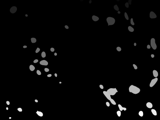
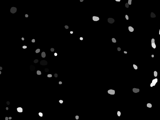
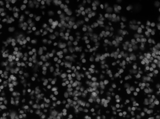
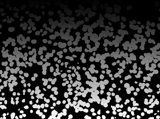
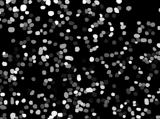
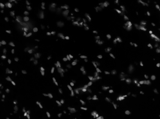
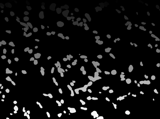
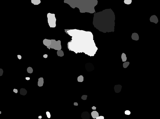
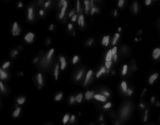
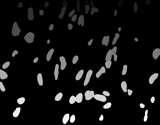
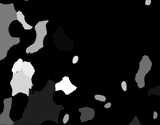

📝 Table written → /content/drive/MyDrive/S-BIAD634/predictions/thumbnail_table.html


In [14]:
# ═══════════════════════════════════════════════════════════════
#  SAFE THUMBNAIL TABLE  •  Original | GT | Cellpose | CellSAM
# ═══════════════════════════════════════════════════════════════
import base64, cv2, numpy as np, pandas as pd
from io import BytesIO
from PIL import Image
from pathlib import Path
from IPython.display import HTML, display

def make_thumb(path, size=160):
    """
    Return an <img> tag with a base64-embedded thumbnail.
    Works for 8-bit, 16-bit, RGB, or single-channel images.
    """
    if not Path(path).exists():
        return "<i>missing</i>"

    arr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if arr is None:
        return "<i>unreadable</i>"

    # --- convert to 8-bit -------------------------------------------------
    if arr.ndim == 2:                             # grayscale / mask
        if arr.dtype != np.uint8:                 # 16-bit or other int
            arr = cv2.normalize(arr, None, 0, 255,
                                 cv2.NORM_MINMAX).astype(np.uint8)
        img_pil = Image.fromarray(arr, mode="L")
    else:                                         # BGR/BGRA
        if arr.shape[2] == 4:
            arr = cv2.cvtColor(arr, cv2.COLOR_BGRA2RGB)
        else:
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(arr)

    # --- make thumbnail & embed -----------------------------------------
    img_pil.thumbnail((size, size))
    buf = BytesIO()
    img_pil.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    return f'<img src="data:image/png;base64,{b64}">'

# ---------- assemble rows -----------------------------------------------
rows = []
for raw_path, gt_path in zip(raw_paths, gt_paths):
    stem     = Path(raw_path).stem
    cp_path  = f"{CP_DIR}/{stem}_cp.png"
    sam_path = f"{SAM_DIR}/{stem}_sam.png"
    rows.append({
        "Original":     make_thumb(raw_path),
        "Ground-truth": make_thumb(gt_path),
        "Cellpose":     make_thumb(cp_path),
        "CellSAM":      make_thumb(sam_path)
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(escape=False)))

# (Optional) save as standalone HTML
out_html = "/content/drive/MyDrive/S-BIAD634/predictions/thumbnail_table.html"
with open(out_html, "w") as f:
    f.write(df.to_html(escape=False))
print("📝 Table written →", out_html)

In [20]:
import os, itertools, textwrap
GT_DIR = "/content/drive/MyDrive/S-BIAD634/dataset/singlecell_groundtruth"

examples = list(itertools.islice(os.scandir(GT_DIR), 30))
print("first few mask filenames:")
for e in examples:
    print("•", e.name)

first few mask filenames:
• Ganglioneuroblastoma_10singlemask.tif
• Neuroblastoma_15singlemask.tif
• Neuroblastoma_13singlemask.tif
• Neuroblastoma_14singlemask.tif
• Neuroblastoma_12singlemask.tif
• Ganglioneuroblastoma_8singlemask.tif
• Neuroblastoma_17singlemask.tif
• Neuroblastoma_16singlemask.tif
• Ganglioneuroblastoma_9singlemask.tif
• Ganglioneuroblastoma_7singlemask.tif
• Ganglioneuroblastoma_6singlemask.tif
• Ganglioneuroblastoma_4singlemask.tif
• normal_26singlemask.tif
• normal_34singlemask.tif
• normal_39singlemask.tif
• normal_40singlemask.tif
• normal_36singlemask.tif
• normal_27singlemask.tif
• normal_30singlemask.tif
• normal_38singlemask.tif
• normal_32singlemask.tif
• normal_31singlemask.tif
• otherspecimen_0singlemask.tif
• otherspecimen_5singlemask.tif
• normal_33singlemask.tif
• otherspecimen_4singlemask.tif
• normal_35singlemask.tif
• otherspecimen_1singlemask.tif
• normal_28singlemask.tif
• normal_29singlemask.tif


In [21]:
from pathlib import Path
import glob, re

def find_mask(folder: Path, stem: str):
    """
    Return the first GT file whose name *contains* <stem>
    (case-insensitive, any extension).
    """
    pattern = str(folder / f"*{stem}*")
    hits = glob.glob(pattern)
    return Path(hits[0]) if hits else None

In [22]:
gt = find_mask(Path(GT_DIR), stem)

In [23]:
# ---------- folders ----------
GT_DIR  = "/content/drive/MyDrive/S-BIAD634/dataset/singlecell_groundtruth"
CP_DIR  = "/content/drive/MyDrive/S-BIAD634/predictions/cellpose"
SAM_DIR = "/content/drive/MyDrive/S-BIAD634/predictions/cellsam"

from pathlib import Path

triples, todo = [], []
for raw_path in raw_paths:                       # ← your trusted list of 10
    stem = Path(raw_path).stem
    gt   = Path(GT_DIR) / f"{stem}singlemask.tif"   # <-- key change
    cp   = Path(CP_DIR) / f"{stem}_cp.png"
    sam  = Path(SAM_DIR) / f"{stem}_sam.png"

    if gt.exists() and cp.exists() and sam.exists():
        triples.append(dict(stem=stem, gt=gt, cp=cp, sam=sam))
    else:
        todo.append(dict(stem=stem, gt_ok=gt.exists(),
                          cp_ok=cp.exists(), sam_ok=sam.exists()))

print(f"✔︎ Complete triples: {len(triples)} / {len(raw_paths)}")
if todo:
    for t in todo:
        print("•", t["stem"],
              "GT"  if not t["gt_ok"]  else "",
              "CP"  if not t["cp_ok"]  else "",
              "SAM" if not t["sam_ok"] else "")

✔︎ Complete triples: 6 / 10
• Ganglioneuroblastoma_0 GT  
• Ganglioneuroblastoma_1 GT  
• Ganglioneuroblastoma_2 GT  
• Ganglioneuroblastoma_3 GT  


In [24]:
import numpy as np, cv2, pandas as pd
from tqdm.auto import tqdm

def binmask(p): return cv2.imread(str(p), cv2.IMREAD_UNCHANGED) > 0
def metrics(gt, pr):
    TP = np.logical_and(gt, pr).sum()
    TN = np.logical_and(~gt, ~pr).sum()
    FP = np.logical_and(~gt, pr).sum()
    FN = np.logical_and(gt, ~pr).sum()
    acc  = (TP+TN)/(TP+TN+FP+FN+1e-9)
    iou  = TP/(TP+FP+FN+1e-9)
    dice = 2*TP/(2*TP+FP+FN+1e-9)
    return acc, iou, dice

rows=[]
for t in tqdm(triples):
    gt = binmask(t["gt"])
    for model, p in [("Cellpose", t["cp"]), ("CellSAM", t["sam"])]:
        pr = binmask(p)
        acc, iou, dice = metrics(gt, pr)
        rows.append(dict(Image=t["stem"], Model=model,
                         Accuracy=acc, IoU=iou, Dice=dice))

df_metrics = pd.DataFrame(rows)
display(df_metrics)
print("\n── Mean scores over 10 images ──")
print(df_metrics.groupby("Model")[["Accuracy","IoU","Dice"]].mean())

  0%|          | 0/6 [00:00<?, ?it/s]

,Image,Model,Accuracy,IoU,Dice
0,Ganglioneuroblastoma_10,Cellpose,0.944854,0.106938,0.193214
1,Ganglioneuroblastoma_10,CellSAM,0.970029,0.163999,0.281786
2,Ganglioneuroblastoma_4,Cellpose,0.879734,0.024331,0.047506
3,Ganglioneuroblastoma_4,CellSAM,0.861251,0.020220,0.039638
4,Ganglioneuroblastoma_6,Cellpose,0.946023,0.062425,0.117514
5,Ganglioneuroblastoma_6,CellSAM,0.960873,0.056597,0.107131
6,Ganglioneuroblastoma_7,Cellpose,0.581855,0.010077,0.019954
7,Ganglioneuroblastoma_7,CellSAM,0.715150,0.013257,0.026168
8,Ganglioneuroblastoma_8,Cellpose,0.864104,0.019316,0.037901
9,Ganglioneuroblastoma_8,CellSAM,0.869614,0.000000,0.000000



── Mean scores over 10 images ──
          Accuracy       IoU      Dice
Model                                 
CellSAM   0.856377  0.044266  0.079585
Cellpose  0.850165  0.049664  0.092574


In [25]:
from shapely.geometry import Polygon
from skimage import measure

def largest_poly(mask):
    lab = measure.label(mask)
    if lab.max()==0: return None
    region = max(measure.regionprops(lab), key=lambda r:r.area)
    coords = [(c[1], c[0]) for c in region.coords]
    return Polygon(coords).buffer(0)

def rcc8(A,B):
    if A is None or B is None: return "undefined"
    if A.disjoint(B):          return "DC"
    if A.touches(B):           return "EC"
    if A.equals(B):            return "EQ"
    if A.within(B):            return "TPP" if A.touches(B.exterior) else "NTPP"
    if B.within(A):            return "TPPi" if B.touches(A.exterior) else "NTPPi"
    return "PO"

rows=[]
for t in triples:
    gt_poly = largest_poly(binmask(t["gt"]))
    for m,p in [("Cellpose", t["cp"]), ("CellSAM", t["sam"])]:
        pr_poly= largest_poly(binmask(p))
        rows.append(dict(Image=t["stem"], Model=m, RCC8=rcc8(gt_poly, pr_poly)))

df_rcc=pd.DataFrame(rows)
display(df_rcc.head())
print("\nRCC-8 counts:")
print(df_rcc.groupby(["Model","RCC8"]).size().unstack(fill_value=0))

,Image,Model,RCC8
0,Ganglioneuroblastoma_10,Cellpose,DC
1,Ganglioneuroblastoma_10,CellSAM,DC
2,Ganglioneuroblastoma_4,Cellpose,DC
3,Ganglioneuroblastoma_4,CellSAM,DC
4,Ganglioneuroblastoma_6,Cellpose,DC



RCC-8 counts:
RCC8      DC
Model       
CellSAM    6
Cellpose   6
